# Description
Using this notebook to inspect instrumens data using IOL Client.<BR>
The idea is to select some to predict returns using alpha factors created from daily bar

# Imports

In [324]:
# Import an settings
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd
from sklearn import set_config
import duckdb as ddb
import talib
from datetime import datetime

from sklearn.metrics import mean_squared_error

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import FunctionTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Ridge
from xgboost import XGBRegressor


import statsmodels.api as sm

from scipy.stats import spearmanr

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
set_config(transform_output="pandas")

# Loading instruments data from DB

In [116]:
# Let's load instruments data from stocks and "cedears".
# Cedears are documents allowing to invest in foreign stocks in BA market Argentina
# Data downloaded on 20-Jul-2026
os.environ["ALGTRAD_PATH"] = "/Users/avrud/projects/ml/algtrad"
db_path = f"{os.getenv('ALGTRAD_PATH', '')}/data/algtrad.db"
print(db_path)
db = ddb.connect(database=db_path, read_only=True)
# Using UNION ALL instead of OR to make it faster"
sql = """
SELECT * FROM instruments_prices WHERE option_type == 'acciones'
UNION ALL
SELECT * FROM instruments_prices WHERE option_type == 'cedears'
"""

ins_df = pd.read_sql(sql, db)
ins_df.head(5)
db.close()

/Users/avrud/projects/ml/algtrad/data/algtrad.db


/var/folders/91/pj4vd_5s35l70m4t_m349m1r0000gn/T/ipykernel_58299/655399749.py:15: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  ins_df = pd.read_sql(sql, db)


## EDA (Basic over Instruments)

In [117]:
# Showing structure
ins_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5106 entries, 0 to 5105
Data columns (total 25 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  5106 non-null   int64         
 1   symbol              5106 non-null   str           
 2   bid_quantity        5106 non-null   int64         
 3   bid_price           5106 non-null   float64       
 4   ask_price           5106 non-null   float64       
 5   ask_quantity        5106 non-null   int64         
 6   close_price         5106 non-null   float64       
 7   percent_change      5106 non-null   float64       
 8   open_price          5106 non-null   float64       
 9   high_price          5106 non-null   float64       
 10  low_price           5106 non-null   float64       
 11  previous_close      5106 non-null   float64       
 12  volume              5106 non-null   int64         
 13  operations_count    5106 non-null   int64         
 14  tim

## Basic instruments data cleaning

In [118]:
# Deleting all null columns
ins_df = ins_df.drop(columns=["strike_price", "expiration_date"])
ins_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5106 entries, 0 to 5105
Data columns (total 23 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  5106 non-null   int64         
 1   symbol              5106 non-null   str           
 2   bid_quantity        5106 non-null   int64         
 3   bid_price           5106 non-null   float64       
 4   ask_price           5106 non-null   float64       
 5   ask_quantity        5106 non-null   int64         
 6   close_price         5106 non-null   float64       
 7   percent_change      5106 non-null   float64       
 8   open_price          5106 non-null   float64       
 9   high_price          5106 non-null   float64       
 10  low_price           5106 non-null   float64       
 11  previous_close      5106 non-null   float64       
 12  volume              5106 non-null   int64         
 13  operations_count    5106 non-null   int64         
 14  tim

In [119]:
# Let's check the count by option type
print("Cedears count:", ins_df[ins_df["option_type"] == "cedears"].shape[0])
print("Stocks count:", ins_df[ins_df["option_type"] == "acciones"].shape[0])

# To make things faster, we'll work with the top 15 volume cedears / stocks (30 in total)
# but first we need to inspect and clean the data

Cedears count: 4623
Stocks count: 483


In [120]:
cols = ["market", "currency", "settlement_term"]
for c in cols:
  print(c)
  print(ins_df[c].value_counts())
  print("-")

market
market
1    5106
Name: count, dtype: int64
-
currency
currency
2    2772
1    2334
Name: count, dtype: int64
-
settlement_term
settlement_term
T1    5106
Name: count, dtype: int64
-


In [121]:
# Removing constant columns
ins_df = ins_df.drop(columns=["market", "settlement_term"])

# Selecting instruments

In [122]:
# Let's check the currency value meaning
ins_df[["symbol", "description", "currency"]].head(10)

,symbol,description,currency
0,A3,Matba Rofex S.A.,1
1,AGRO,Agrometal,1
2,ALUA,Aluar,1
3,ALUAD,Aluar,2
4,APBRA,Petroleo Brasileiro (Preferidas),1
5,AUSO,Autopistas del Sol,1
6,BBAR,Bbva,1
7,BBARD,Bbva,2
8,BHIP,Banco Hipotecario,1
9,BMA,Banco Macro,1


In [123]:
# Stocks ending in "D" are in USD dollar. So, 1 --> Peso Arg (ARS) and 2 --> Dollar (USD)
# Cedears are only in USD
# Let's add the symbol
ins_df["curr_symbol"] = ins_df["currency"].map(lambda x: "ARS" if x == "1" else "USD")
ins_df[["symbol", "description", "currency", "curr_symbol"]].head(10)

,symbol,description,currency,curr_symbol
0,A3,Matba Rofex S.A.,1,ARS
1,AGRO,Agrometal,1,ARS
2,ALUA,Aluar,1,ARS
3,ALUAD,Aluar,2,USD
4,APBRA,Petroleo Brasileiro (Preferidas),1,ARS
5,AUSO,Autopistas del Sol,1,ARS
6,BBAR,Bbva,1,ARS
7,BBARD,Bbva,2,USD
8,BHIP,Banco Hipotecario,1,ARS
9,BMA,Banco Macro,1,ARS


While a good approach would be to compute the rollover average of n last days, let's use the available data to start selecting cedears and stocks.
In the future, having a better source of data this can be improved.

### Conditions
1. Using instruments with USD currency to avoid conversion complexity
2. Using top 15 dollar volumen for stocks and top 15 dollar volumen for cedears (30 in total)



In [124]:
# Get instruments values in USD
ins_df = ins_df[ins_df["curr_symbol"] == "USD"]

# Dollar volume = volume * close_price
# So, volume > 0 and last_price > 0 is needed
ins_df = ins_df[(ins_df["volume"] > 0) & (ins_df["close_price"] > 0)]
# Computing liquidity
ins_df["dollar_volume"] = ins_df["volume"] * ins_df["close_price"]


print("Current count:", ins_df.shape[0])
ins_df.head()
    
  

Current count: 1776


,id,symbol,bid_quantity,bid_price,ask_price,ask_quantity,close_price,percent_change,open_price,high_price,low_price,previous_close,volume,operations_count,timestamp,option_type,currency,description,minimum_lot_size,lot_size,download_timestamp,curr_symbol,dollar_volume
3,3801,ALUAD,10,0.610,0.670,86,0.635,1.76,0.627,0.638,0.624,0.635,824,72,2026-07-20T16:55:02.82,acciones,2,Aluar,1,1,2026-07-20 20:48:38.204459,USD,523.24
7,3805,BBARD,3218,4.660,7.300,421,6.820,1.79,6.700,6.830,6.590,6.820,5449,68,2026-07-20T16:48:29.72,acciones,2,Bbva,1,1,2026-07-20 20:48:38.204459,USD,37162.18
10,3808,BMA.D,25,8.800,10.350,451,9.510,1.82,9.310,9.680,9.210,9.510,3862,113,2026-07-20T16:49:49.707,acciones,2,Banco Macro,1,1,2026-07-20 20:48:38.204459,USD,36727.62
14,3812,BYMAD,10000,0.011,0.222,79079,0.195,-1.51,0.199,0.200,0.191,0.195,33942,182,2026-07-20T16:58:39.53,acciones,2,Bolsas Y Mercados Argentinos S.A.,1,1,2026-07-20 20:48:38.204459,USD,6618.69
21,3819,CEPUD,28,1.480,1.660,9204,1.490,-0.99,1.480,1.520,1.470,1.490,5745,113,2026-07-20T16:58:32.68,acciones,2,Central Puerto Sa,1,1,2026-07-20 20:48:38.204459,USD,8560.05


In [125]:
# Creating a new dataframe with selected instruments.
stocks_df = ins_df[ins_df["option_type"] == "acciones"][["symbol", "description", "dollar_volume", "volume", "close_price", "option_type"]].sort_values(by="dollar_volume", ascending=False).head(15)
cedears_df = ins_df[ins_df["option_type"] == "cedears"][["symbol", "description", "dollar_volume", "volume", "close_price", "option_type"]].sort_values(by="dollar_volume", ascending=False).head(15)
selected_df = pd.concat([stocks_df, cedears_df])

In [126]:
selected_df.sort_values(by="dollar_volume", ascending=False)


,symbol,description,dollar_volume,volume,close_price,option_type
4691,MSFTD,Cedear Microsoft Corp.,2777465.300,174245,15.940,cedears
4666,METAD,"Cedear Facebook, Inc.",1728161.600,72490,23.840,cedears
3772,MUD,Cedear Micron Technology Inc,1557981.000,9111,171.000,cedears
4234,AMZND,"Cedear Amazon.Com, Inc",1456614.080,750832,1.940,cedears
2656,GOGLD,Cedear Google Inc.,1220934.800,210506,5.800,cedears
1738,GOGLD,Cedear Google Inc.,1211833.680,213351,5.680,cedears
3068,SPYD,Cedear Spdr S&P 500,1184221.360,91658,12.920,cedears
4698,MUD,Cedear Micron Technology Inc,1146834.000,6591,174.000,cedears
4914,SPYD,Cedear Spdr S&P 500,1087385.600,83968,12.950,cedears
482,YPFDD,Ypf,1014413.400,18579,54.600,acciones


In [127]:
# Now that the 30 instruments are selected, let's create the list of symbols to retrieve OHLCV
# data using the daily-bar service from the cli utility.
symbols = selected_df["symbol"].tolist()
symbols = " ,".join(symbols)
symbols

'YPFDD ,GGALD ,YPFDD ,YPFDD ,YPFDD ,PAMPD ,GGALD ,YPFDD ,PAMPD ,PAMPD ,BMA.D ,PAMPD ,CEPUD ,GGALD ,PAMPD ,MSFTD ,METAD ,MUD ,AMZND ,GOGLD ,GOGLD ,SPYD ,MUD ,SPYD ,AAPLD ,MELID ,VISTD ,MSFTD ,GOGLD ,SPYD'

# Loading OHLCV data 
Data downloaded using the daily-bar-history utility in cli. It will be used to compute alpha factors.


In [128]:
# Let's save the selected symbols in the database just o maintain a history
# for future updates
db = ddb.connect(database=db_path, read_only=False)
ts = int(datetime.strptime("2026-07-02", "%Y-%m-%d").timestamp())
row = (symbols, ts, ts) 
db.execute("INSERT INTO selected_tickers (ticker_list, rol_avg_start_date, rol_avg_end_date)  VALUES(?, ?, ?)", row)
db.close()

In [129]:
# After un the daily-bar-history utility in cli, the OHLCV data is available
# Some SQL queries saved in scripts/useful_queries.sql were run and some inconsistencies in data were notices.
# Let's check and fix them now
db = ddb.connect(database=db_path, read_only=True)
# Using UNION ALL instead of OR to make it faster"
sql = "SELECT * FROM daily_bar_history"

dbar_df = pd.read_sql(sql, db)
db.close()
dbar_df.head(5)


/var/folders/91/pj4vd_5s35l70m4t_m349m1r0000gn/T/ipykernel_58299/3164955429.py:8: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  dbar_df = pd.read_sql(sql, db)


,id,ticker,date,open,high,low,close,volume
0,1284,BMA.D,1704153600,-1.000000,-1.000000,-1.000000,-1.000000,-1
1,1285,REITD,1704153600,-1.000000,-1.000000,-1.000000,-1.000000,-1
2,1286,AMDD,1704153600,13.900000,14.700000,13.800000,14.000000,939
3,1287,BABAD,1704153600,8.211825,8.211825,7.734394,8.144984,2317
4,1288,BBARD,1704153600,-1.000000,-1.000000,-1.000000,-1.000000,-1


# Cleaning OHLCV data

In [130]:
# daily-bar-history utility replace nans by -1.
# A check will be run to determine if the data can be used and for wich tickers
dbar_df.drop(columns="id", inplace=True)
states_by_ticker_df = (
  dbar_df.groupby("ticker")
  .agg(has_data=("open", lambda x: (x > -1).sum()),
       no_data=("open", lambda x: (x == -1).sum()),
       row_count=("open", "count"),
       porc_data=("open", lambda x: ((x > -1).sum() / x.count() * 100).round(2)),
      )
).reset_index()

states_by_ticker_df

,ticker,has_data,no_data,row_count,porc_data
0,AMDD,632,1,633,99.84
1,BABAD,632,1,633,99.84
2,BBARD,482,151,633,76.15
3,BMA.D,0,633,633,0.00
4,BYMAD,499,134,633,78.83
5,CEPUD,499,134,633,78.83
6,ECOGD,302,331,633,47.71
7,GGALD,631,2,633,99.68
8,GOGLD,631,2,633,99.68
9,IBITD,396,237,633,62.56


In [131]:
# How many with less than 75% of data available?
missing_df = states_by_ticker_df[states_by_ticker_df["porc_data"] < 75]
# Let's add a date string first to make it easier to read
dbar_df["date_str"] = dbar_df["date"].map(lambda x: datetime.fromtimestamp(x).strftime("%Y-%m-%d"))
# Before checking, let's remove tickers having less than 65% of data available. Data is not enough to compute trustable alpha factors
dbar_cpy_df = dbar_df.copy() # Just in case a copy
dbar_df = dbar_df[~dbar_df["ticker"].isin(missing_df[missing_df["porc_data"] < 65.0]["ticker"].tolist())]

print("Usable tickers count:", len(dbar_df.groupby("ticker")["ticker"].count().index.tolist()))

# Trying to find out why  some data is missing
# Also removing the ones having < 65
missing_df = missing_df[missing_df["porc_data"] > 64.0]
missing_df.sort_values("porc_data", ascending=False)
ori_miss_df = dbar_df[dbar_df["ticker"].isin(missing_df["ticker"].tolist())]
ori_miss_df[["ticker", "date_str", "date", "volume"]].sort_values(["ticker", "date"])
# Displaying tickers side by side to check if there is a pattern in missing data
ori_miss_df.drop(columns=["date"], inplace=True)
ori_miss_df.pivot(index="date_str", columns="ticker", values="volume").sort_index(ascending=True)


Usable tickers count: 23


ticker,LOMAD,ORCLD,TGN4D,TGSUD
date_str,,,,
2024-01-01,-1,-1,-1,-1
2024-01-02,-1,2,-1,-1
2024-01-03,-1,-1,-1,-1
2024-01-04,-1,-1,-1,-1
2024-01-07,-1,-1,-1,-1
2024-01-08,-1,-1,-1,-1
2024-01-09,-1,-1,-1,-1
2024-01-10,-1,-1,-1,-1
2024-01-11,-1,-1,-1,-1


In [132]:
# Once removed the tickers with a lot of missing data it's time to clean the remaining ones.
# It would be better to have a more records for ticker but for now its ok. That will be improved in future iterations
dbar_df = dbar_df[dbar_df["open"] > -1]
dbar_df[dbar_df["open"] == -1]

,ticker,date,open,high,low,close,volume,date_str


In [133]:
dbar_df.index

Index([    2,     3,     8,     9,    11,    12,    14,    15,    18,    22,
       ...
       18976, 18978, 18979, 18980, 18982, 18983, 18985, 18987, 18988, 18989],
      dtype='int64', length=13231)

# Feature Engineering 

## Computing Indicators

In [134]:
# Time to start creating alpha factors
# Since it's better to compute several AF at the same time, a function is created
# For now, just adding indicators. The data will be normalized when needed in EDA stage
def compute_indicators(group):
    close = group["close"].astype(float).values
    # Relative Strength Index, 14 days
    group["rsi_14"] = talib.RSI(close, timeperiod=14)
    # Simple Moving Average, 20 days
    group["sma_20"] = talib.SMA(close, timeperiod=20)
    # Exponential moving average 100 days, usefull in combination with MACD
    group["ema_100"] = talib.EMA(close, timeperiod=100)
    # Moving Average Convergence Divergence, 12, 26, 9 days (default values)
    group["macd"], group["MACD_signal"], _ = talib.MACD(close, fastperiod=12, slowperiod=26, signalperiod=9)
    # Bollinger Bands
    high, mid, low = talib.BBANDS(close, timeperiod=20, nbdevup=2, nbdevdn=2, matype=0)
    # Expressing bands in percentage difference to close price
    group["bb_upper"] = (high - group["close"]) / high
    group["bb_lower"] =  (group["close"] - low) / group["close"]
    # Average True Range
    group["atr"] = talib.ATR(group["high"], group["low"], group["close"], timeperiod=14)
    return group

# Creating the alpha factors dataframe
af_df = dbar_df.copy()
af_df = af_df.groupby("ticker").apply(compute_indicators)

af_df[130:140]


date       open   high    low      close  volume  \
ticker                                                                
AMDD   3932  1721260800  16.299999  16.50  15.40  15.800000    2607   
       3962  1721347200  16.350000  16.35  15.30  15.450000    2004   
       3992  1721606400  15.850000  16.75  15.60  16.700001    1905   
       4022  1721692800  16.150000  16.15  15.55  15.600000    2635   
       4052  1721779200  15.450000  15.45  14.55  14.750000    1988   
       4082  1721865600  14.700000  14.70  13.65  14.050000    3268   
       4112  1721952000  14.000000  14.35  13.75  13.950000     774   
       4142  1722211200  14.100000  14.30  13.55  13.750000    1475   
       4172  1722297600  13.800000  14.05  13.25  13.700000    3045   
       4202  1722384000  14.750000  15.40  14.25  14.450000    2416   

               date_str     rsi_14   sma_20    ema_100      macd  MACD_signal  \
ticker                                                                          
AMDD   3932  2024-07-17  39.370260  16.9175  17.413676  0.114483     0.195182   
       3962  2024-07-18  37.185799  16.8900  17.374791 -0.032495     0.149646   
       3992  2024-07-21  48.233066  16.9250  17.361429 -0.047564     0.110204   
       4022  2024-07-22  41.342418  16.8825  17.326549 -0.146577     0.058848   
       4052  2024-07-23  36.949666  16.8150  17.275528 -0.290287    -0.010979   
       4082  2024-07-24  33.767632  16.7225  17.211656 -0.455413    -0.099866   
       4112  2024-07-25  33.326095  16.6075  17.147069 -0.587573    -0.197407   
       4142  2024-07-28  32.413240  16.4675  17.079800 -0.700375    -0.298001   
       4172  2024-07-29  32.175952  16.3575  17.012874 -0.784760    -0.395353   
       4202  2024-07-30  39.348431  16.2450  16.962124 -0.782101    -0.472702   

             bb_upper  bb_lower       atr  
ticker                                     
AMDD   3932  0.160112  0.049180  0.907876  
       3962  0.180449  0.033772  0.918028  
       3992  0.113898  0.101592  0.945312  
       4022  0.173743  0.045854  0.959932  
       4052  0.223552  0.007916  0.966366  
       4082  0.267839 -0.014606  0.975911  
       4112  0.279110  0.006171  0.949060  
       4142  0.294185  0.021528  0.934842  
       4172  0.300946  0.042548  0.925210  
       4202  0.262181  0.106903  0.980552

In [135]:
af_df = af_df.reset_index(level=1, drop=True).reset_index()

In [136]:


af_df.head()

,ticker,date,open,high,low,close,volume,date_str,rsi_14,sma_20,ema_100,macd,MACD_signal,bb_upper,bb_lower,atr
0,AMDD,1704153600,13.90,14.700000,13.80,14.00,939,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,AMDD,1704240000,14.25,14.700000,13.65,13.80,638,2024-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,AMDD,1704326400,14.40,14.800000,13.55,14.30,489,2024-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,AMDD,1704412800,14.70,14.800000,14.05,14.45,1151,2024-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,AMDD,1704672000,14.60,16.299999,13.95,16.25,1954,2024-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Computing Returns

### Lagged

In [137]:
# Before computing lagged returns, let's winsorize extreme outliers.
# Checking by percentiles
ret = af_df.groupby("ticker")["close"].pct_change()
perc = [.0001, .001, .01]
perc+=[1 - p for p in perc]
perc.sort()
print("All percentiles:", perc)
ret = ret.describe(percentiles=perc)
ret = ret.to_frame("%").iloc[2:].style.format(lambda x: f"{x:,.2%}")
ret

All percentiles: [0.0001, 0.001, 0.01, 0.99, 0.999, 0.9999]


,%
std,4.77%
min,-89.91%
0.01%,-82.24%
0.1%,-19.33%
1%,-8.30%
99%,10.45%
99.9%,31.93%
99.99%,156.88%
max,229.49%


In [138]:
# Lagged returns
def compute_lagged_returns(group, lags, q):
  for lag in lags:
    # 1. pct_change. % Change from 'lag' days
    # 2. Clip - Winzorizing
    # 2. Add -  Convert to growth factor for 'lag'
    # 3. Pow(1 / lag) -  Compounded growth factor per day 
    # 4. Sub(1) -  Average compounded return per day
    # This way values are comparable across different lags. 
    # For example, a 10% return in 1 day is not the same as a 10% return in 10 days.
    group[f"return_{lag}d"] = group["close"].pct_change(lag) \
      .pipe(lambda x: x.clip(lower=x.quantile(q), upper=x.quantile(1 - q))) \
      .add(1) \
      .pow(1 / lag) \
      .sub(1) # Back to percentage return

  return group

# Once computed lagged returns, adding for 1-21 lags for 5 prior periods to use as features 
def add_previous_laggs_returns(group, lags, periods):
  for p in periods:
    for lag in lags:
      group[f"return_{p}p_{lag}d"] = group[f"return_{lag}d"].shift(p * lag)

  return group

# There are extreme outilers in returns. Let's winsorize them using the 0.1% and 99.9% percentiles
q = 0.01
# 1 day, 1, 2 weeks, 1, 2, 3 months
lags = [1, 5, 10, 21, 42, 63]
# Adding lagged returns k
returns_df = af_df.groupby("ticker").apply(compute_lagged_returns, lags=lags, q=q).reset_index(level=1, drop=True).reset_index()
#returns_df = af_df.groupby("ticker").apply(compute_lagged_returns, lags=lags, q=q).reset_index()
# Once computed lagged returns, adding for 1-21 lags for 5 prior periods to use as features 
returns_df = returns_df.groupby("ticker") \
  .apply(add_previous_laggs_returns, lags=lags[:4], periods=[1, 2, 3, 4, 5]) \
  .reset_index(level=1, drop=True).reset_index()

# checking...
returns_df[returns_df["ticker"] == "MELID"][["ticker", "date_str", "return_1p_21d", "return_5p_10d"]].reset_index(drop=True)



,ticker,date_str,return_1p_21d,return_5p_10d
0,MELID,2024-01-01,NaN,NaN
1,MELID,2024-01-02,NaN,NaN
2,MELID,2024-01-03,NaN,NaN
3,MELID,2024-01-04,NaN,NaN
4,MELID,2024-01-07,NaN,NaN
5,MELID,2024-01-08,NaN,NaN
6,MELID,2024-01-09,NaN,NaN
7,MELID,2024-01-10,NaN,NaN
8,MELID,2024-01-11,NaN,NaN
9,MELID,2024-01-14,NaN,NaN


### Forward 

In [139]:
# Adding Forward returns to use as a target
# Past returns are moved by 'lag' days
# to "n" days before.
# The idea is figure out what is the best lag to predict returns by using them all and then compare.
f_lags = [1, 5, 10, 21]
fwdret_df = returns_df.copy()#.groupby("ticker").apply(add_fwd_ret, lags=f_lags).reset_index(level=1, drop=True).reset_index()
# for lag in lags:
#     fwdret_df[f"target_return_{lag}d"] = fwdret_df.groupby("ticker")[f"return_{lag}d"].shift(-lag)

for lag in f_lags:
  fwdret_df[f"target_return_{lag}d"] = fwdret_df.groupby("ticker")[f"return_{lag}d"].shift(-lag)

cols = ["ticker", "date", "close", "volume", "date_str"]
for i in f_lags:
  cols.append(f"return_{i}d")
  cols.append(f"target_return_{i}d")


main_df = fwdret_df.copy()
fwdret_df[cols].sort_values(by=["ticker", "date"]).head(20)


,ticker,date,close,volume,date_str,return_1d,target_return_1d,return_5d,target_return_5d,return_10d,target_return_10d,return_21d,target_return_21d
0,AMDD,1704153600,14.000000,939,2024-01-01,NaN,-0.014286,NaN,0.023836,NaN,0.015327,NaN,0.011771
1,AMDD,1704240000,13.800000,638,2024-01-02,-0.014286,0.036232,NaN,0.024824,NaN,0.018645,NaN,0.012733
2,AMDD,1704326400,14.300000,489,2024-01-03,0.036232,0.010489,NaN,0.014932,NaN,0.023845,NaN,0.011682
3,AMDD,1704412800,14.450000,1151,2024-01-04,0.010489,0.112269,NaN,0.011497,NaN,0.024181,NaN,0.012224
4,AMDD,1704672000,16.250000,1954,2024-01-07,0.112269,-0.030769,NaN,-0.008131,NaN,0.012778,NaN,0.005279
5,AMDD,1704758400,15.750000,1609,2024-01-08,-0.030769,-0.009524,0.023836,0.006889,NaN,0.014284,NaN,0.007040
6,AMDD,1704844800,15.600000,359,2024-01-09,-0.009524,-0.012821,0.024824,0.012504,NaN,0.020715,NaN,0.007236
7,AMDD,1704931200,15.400000,850,2024-01-10,-0.012821,-0.006493,0.014932,0.032836,NaN,0.029520,NaN,0.008381
8,AMDD,1705017600,15.300000,660,2024-01-11,-0.006493,0.019608,0.011497,0.037024,NaN,0.024026,NaN,0.009730
9,AMDD,1705276800,15.600000,677,2024-01-14,0.019608,0.044872,-0.008131,0.034128,NaN,0.020715,NaN,0.009307


## Sectors

In [140]:
# Getting sectors from CSV file created from Several internet sources
# A free source for this data was not found, so, this csv is manually created. 
# Also, this information does not vary, in consequence a process to get it is not needed.
sectors_path = f"{os.getenv('ALGTRAD_PATH', '')}/data/sectors.csv"
print("Sectors path:", sectors_path)
sectors_df = pd.read_csv(sectors_path)
sectors_df.head()

Sectors path: /Users/avrud/projects/ml/algtrad/data/sectors.csv


,ticker,underlying_ticker,company,country,asset_type,market_theme,sector,subindustry
0,YPFDD,YPFD,YPF S.A.,Argentina,Stock,Commodity,Energy,Oil & Gas Integrated
1,PAMPD,PAMP,Pampa Energía,Argentina,Stock,Defensive,Utilities,Independent Power Producers & Energy Traders
2,GGALD,GGAL,Grupo Financiero Galicia,Argentina,Stock,Financial,Financials,Diversified Banks
3,BBARD,BBAR,BBVA Argentina,Argentina,Stock,Financial,Financials,Diversified Banks
4,BMA.D,BMA,Banco Macro,Argentina,Stock,Financial,Financials,Diversified Banks


In [141]:
sectors_df.groupby("sector")["sector"].agg("count")
# There are 3 rows having "ETF" as sector... It is necessary to check it

sector
Consumer Discretionary    2
Consumer Staples          1
ETF                       3
Energy                    4
Financials                6
Information Technology    7
Materials                 2
Real Estate               1
Utilities                 4
Name: sector, dtype: int64

In [142]:
sectors_df[sectors_df["sector"] == "ETF"]

# SPYD S&P Index ETF in USD -> Multi sector ETF
# QQQD Invesco QQQ Trust ETF in USD -> Tech sector 
# IBITD  Bitcoin related ETF

,ticker,underlying_ticker,company,country,asset_type,market_theme,sector,subindustry
15,SPYD,SPY,SPDR S&P 500 ETF Trust,United States,ETF,Fund,ETF,S&P 500 ETF
22,QQQD,QQQ,Invesco QQQ Trust,United States,ETF,Fund,ETF,NASDAQ-100 ETF
23,IBITD,IBIT,iShares Bitcoin Trust,United States,ETF,Fund,ETF,Spot Bitcoin ETF


In [143]:
# Checking sectors and countries
sectors_df[["ticker", "company", "country", "asset_type", "sector"]]
# After fixing some countries and sectors, let's merge the data with the main dataframe

,ticker,company,country,asset_type,sector
0,YPFDD,YPF S.A.,Argentina,Stock,Energy
1,PAMPD,Pampa Energía,Argentina,Stock,Utilities
2,GGALD,Grupo Financiero Galicia,Argentina,Stock,Financials
3,BBARD,BBVA Argentina,Argentina,Stock,Financials
4,BMA.D,Banco Macro,Argentina,Stock,Financials
5,TGSUD,Transportadora de Gas del Sur,Argentina,Stock,Energy
6,LOMAD,Loma Negra,Argentina,Stock,Materials
7,CEPUD,Central Puerto,Argentina,Stock,Utilities
8,SUPVD,Grupo Supervielle,Argentina,Stock,Financials
9,BYMAD,Bolsas y Mercados Argentinos,Argentina,Stock,Financials


In [144]:
# Mergin sectors data with main_df
main_df = main_df.merge(sectors_df[["ticker", "country", "asset_type", "sector"]], on="ticker", how="left")
main_df.head(20)

,ticker,date,open,high,low,close,volume,date_str,rsi_14,sma_20,ema_100,macd,MACD_signal,bb_upper,bb_lower,atr,return_1d,return_5d,return_10d,return_21d,return_42d,return_63d,return_1p_1d,return_1p_5d,return_1p_10d,return_1p_21d,return_2p_1d,return_2p_5d,return_2p_10d,return_2p_21d,return_3p_1d,return_3p_5d,return_3p_10d,return_3p_21d,return_4p_1d,return_4p_5d,return_4p_10d,return_4p_21d,return_5p_1d,return_5p_5d,return_5p_10d,return_5p_21d,target_return_1d,target_return_5d,target_return_10d,target_return_21d,country,asset_type,sector
0,AMDD,1704153600,13.900000,14.700000,13.800000,14.000000,939,2024-01-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.014286,0.023836,0.015327,0.011771,United States,CEDEAR,Information Technology
1,AMDD,1704240000,14.250000,14.700000,13.650000,13.800000,638,2024-01-02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.014286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036232,0.024824,0.018645,0.012733,United States,CEDEAR,Information Technology
2,AMDD,1704326400,14.400000,14.800000,13.550000,14.300000,489,2024-01-03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.036232,NaN,NaN,NaN,NaN,NaN,-0.014286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010489,0.014932,0.023845,0.011682,United States,CEDEAR,Information Technology
3,AMDD,1704412800,14.700000,14.800000,14.050000,14.450000,1151,2024-01-04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.010489,NaN,NaN,NaN,NaN,NaN,0.036232,NaN,NaN,NaN,-0.014286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112269,0.011497,0.024181,0.012224,United States,CEDEAR,Information Technology
4,AMDD,1704672000,14.600000,16.299999,13.950000,16.250000,1954,2024-01-07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.112269,NaN,NaN,NaN,NaN,NaN,0.010489,NaN,NaN,NaN,0.036232,NaN,NaN,NaN,-0.014286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.030769,-0.008131,0.012778,0.005279,United States,CEDEAR,Information Technology
5,AMDD,1704758400,15.950000,16.500000,15.100000,15.750000,1609,2024-01-08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.030769,0.023836,NaN,NaN,NaN,NaN,0.112269,NaN,NaN,NaN,0.010489,NaN,NaN,NaN,0.036232,NaN,NaN,NaN,-0.014286,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009524,0.006889,0.014284,0.007040,United States,CEDEAR,Information Technology
6,AMDD,1704844800,16.450001,16.450001,15.300000,15.600000,359,2024-01-09,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.009524,0.024824,NaN,NaN,NaN,NaN,-0.030769,NaN,NaN,NaN,0.112269,NaN,NaN,NaN,0.010489,NaN,NaN,NaN,0.036232,NaN,NaN,NaN,-0.014286,NaN,NaN,NaN,-0.012821,0.012504,0.020715,0.007236,United States,CEDEAR,Information Technology
7,AMDD,1704931200,15.600000,16.400000,15.000000,15.400000,850,2024-01-10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.012821,0.014932,NaN,NaN,NaN,NaN,-0.009524,NaN,NaN,NaN,-0.030769,NaN,NaN,NaN,0.112269,NaN,NaN,NaN,0.010489,NaN,NaN,NaN,0.036232,NaN,NaN,NaN,-0.006493,0.032836,0.029520,0.008381,United States,CEDEAR,Information Technology
8,AMDD,1705017600,15.650000,15.950000,14.650000,15.300000,660,2024-01-11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.006493,0.011497,NaN,NaN,NaN,NaN,-0.012821,NaN,NaN,NaN,-0.009524,NaN,NaN,NaN,-0.030769,NaN,NaN,NaN,0.112269,NaN,NaN,NaN,0.010489,NaN,NaN,NaN,0.019608,0.037024,0.024026,0.009730,United States,CEDEAR,Information Technology
9,AMDD,1705276800,15.000000,16.250000,15.000000,15.600000,677,2024-01-14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.019608,-0.008131,NaN,NaN,NaN,NaN,-0.006493,NaN,NaN,NaN,-0.012821,NaN,NaN,NaN,-0.009524,NaN,NaN,NaN,-0.030769,NaN,NaN,NaN,0.112269,NaN,NaN,NaN,0.044872,0.034128,0.020715,0.009307,United States,CEDEAR,Information Technology


# EDA (Eng.Features)

There are some data available to start exploring and performing some tests.<BR>
Here is a list of tasks and ideas to explore:

1. There are columns having NaN values created as a consequence of time based features. Linear Models doesn't handle that values, so some sort of processing is needed.
2. Format dates or create sub features to make sure the data has the correct meaning for the model
3. Check feature distributions and apply log/sqr or some sort of standarization / scaling
4. Common CV validation strategies dont work for timeseries data. Apply some timeseries CV.
5. Using 2 years OHLCV  data is not enought due to the large amount onf Nan values created when computing some indicators. Using this period for a PoC.
6. Checking Sector, Country and Asset type data.


## Observations

1. RSI_14 has a close to normal distribution, having a very small right skew and some 0 outilers.
2. Bollinger bands have a severe right skew.
3. 20-30% of rows adquire null columns when creating indexes when using a period of 2 years for OHLCV data.
4. Month is cyclical... Leaving as it is for now. Try OHE or cyclical encoding.

In [145]:
print("all", main_df.shape[0])
summ_df = \
main_df.groupby("ticker").agg(count=("ticker", "count")).sort_values(by="ticker").reset_index().merge( \
main_df[main_df.isna().any(axis=1)].groupby("ticker").agg(count=("ticker", "count")).sort_values(by="ticker").reset_index(), \
  on="ticker", how="inner", suffixes=["_all", "_null"])

summ_df["%null"] = np.round(summ_df["count_null"] / summ_df["count_all"] * 100, 2)
summ_df


all 13231


,ticker,count_all,count_null,%null
0,AMDD,632,147,23.26
1,BABAD,632,147,23.26
2,BBARD,482,147,30.50
3,BYMAD,499,147,29.46
4,CEPUD,499,147,29.46
5,GGALD,631,147,23.30
6,GOGLD,631,147,23.30
7,IBMD,632,147,23.26
8,KOD,632,147,23.26
9,LOMAD,474,147,31.01


In [146]:
# Removing rows having Nan data. They became unusable for training in this domain.
main_df = main_df.dropna()
main_df.info(show_counts=True)

<class 'pandas.DataFrame'>
Index: 9850 entries, 126 to 13209
Data columns (total 49 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   ticker             9850 non-null   str    
 1   date               9850 non-null   int64  
 2   open               9850 non-null   float64
 3   high               9850 non-null   float64
 4   low                9850 non-null   float64
 5   close              9850 non-null   float64
 6   volume             9850 non-null   int64  
 7   date_str           9850 non-null   str    
 8   rsi_14             9850 non-null   float64
 9   sma_20             9850 non-null   float64
 10  ema_100            9850 non-null   float64
 11  macd               9850 non-null   float64
 12  MACD_signal        9850 non-null   float64
 13  bb_upper           9850 non-null   float64
 14  bb_lower           9850 non-null   float64
 15  atr                9850 non-null   float64
 16  return_1d          9850 non-null   fl

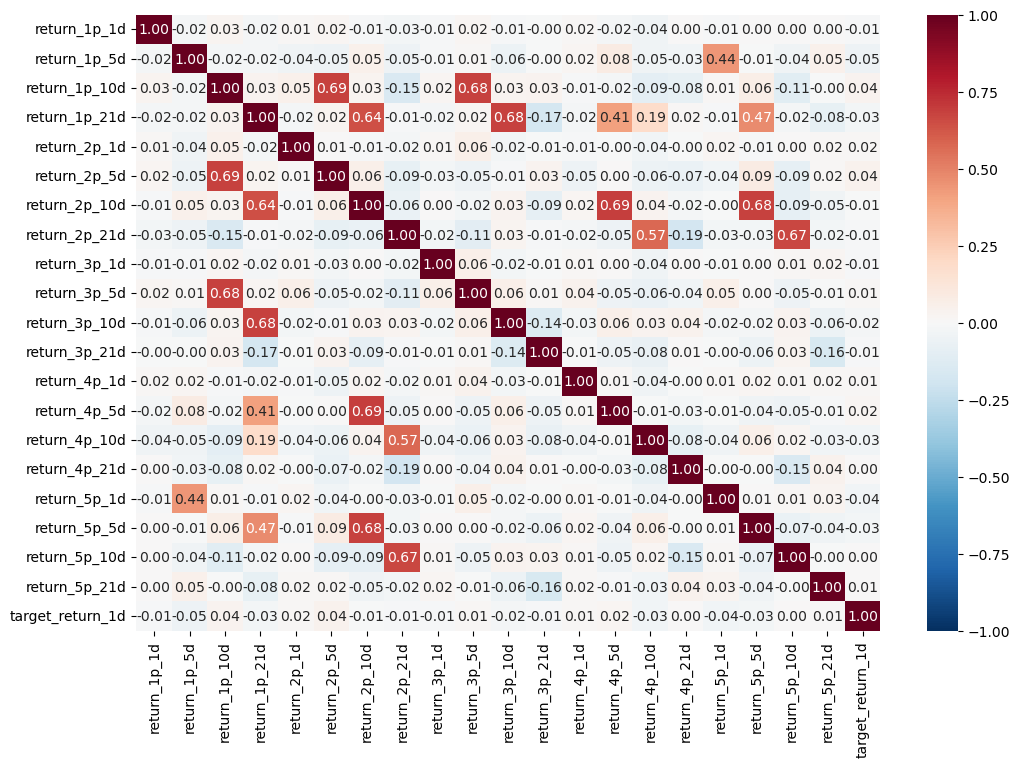

In [147]:
# Checking correlations
target_days = [1, 5, 10, 21]
target_cols = [f"target_return_{x}d" for x in target_days]
target_df = main_df[target_cols]

lag_days = ["1", "5", "10", "21"]
lag_ret_cols = []
for p in [1, 2, 3, 4, 5]:
  lag_ret_cols.extend([f"return_{p}p_{x}d" for x in lag_days])

corr_df = main_df.drop(columns=target_cols)
corr_df = corr_df.drop(columns=["date_str"])
corr_df = corr_df.drop(columns=["ticker"])

# corr_df = corr_df[["rsi_14", "sma_20", "ema_100", "MACD_signal"]] \
#corr_df = corr_df[["rsi_14", "sma_20", "ema_100", "MACD_signal", "bb_upper", "bb_middle", "bb_lower", "atr"]] \
corr_df = corr_df[lag_ret_cols] \
  .join(target_df[["target_return_1d"]]).corr()
  #.join(target_df[["target_return_1d", "target_return_5d", "target_return_10d", "target_return_21d"]]).corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr_df, cmap="RdBu_r", annot=True, fmt=".2f", center=0, vmin=-1, vmax=1)
plt.show()

# Most Features are correlated because they are computed based on the close price
# Also, each feature is not directly correlated with returns, but the should be in combination with other faeatures. 
# Let's check that in future steps.

skew z: 0.22817230501453745
skew nz: 0.22817230501453745


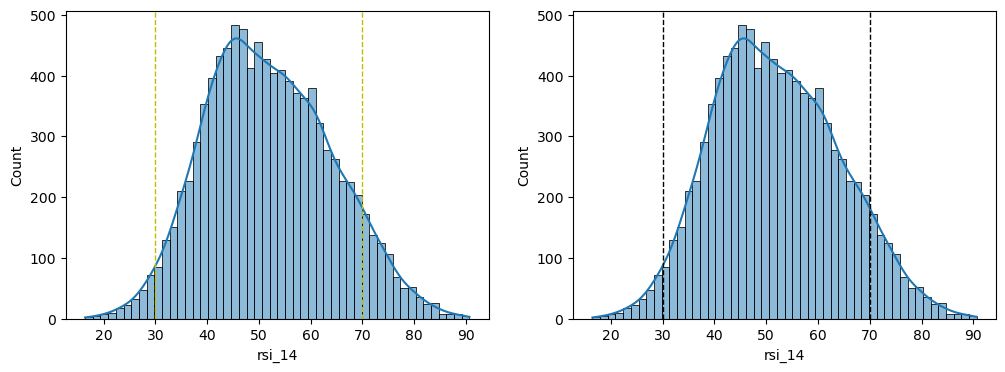

In [148]:
#  Checking RSI distribution

print("skew z:", main_df["rsi_14"].skew())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(main_df["rsi_14"].dropna(), bins=50, kde=True, ax=axes[0])
axes[0].axvline(30, ls="--", lw=1, c="y")
axes[0].axvline(70, ls="--", lw=1, c="y")
noz_df = main_df[main_df["rsi_14"] != 0]
print("skew nz:", noz_df["rsi_14"].skew())

sns.histplot(noz_df["rsi_14"].dropna(), bins=50, kde=True, ax=axes[1])
axes[1].axvline(30, ls="--", lw=1, c="k")
axes[1].axvline(70, ls="--", lw=1, c="k")

# There is a very small right skew but there are also some 0 outliers that diminish the skew.
# Still the distribution is close to normal.

Skew bb_lower : 2.1132800927530098
Skew bb_upper : 1.2374325888420854


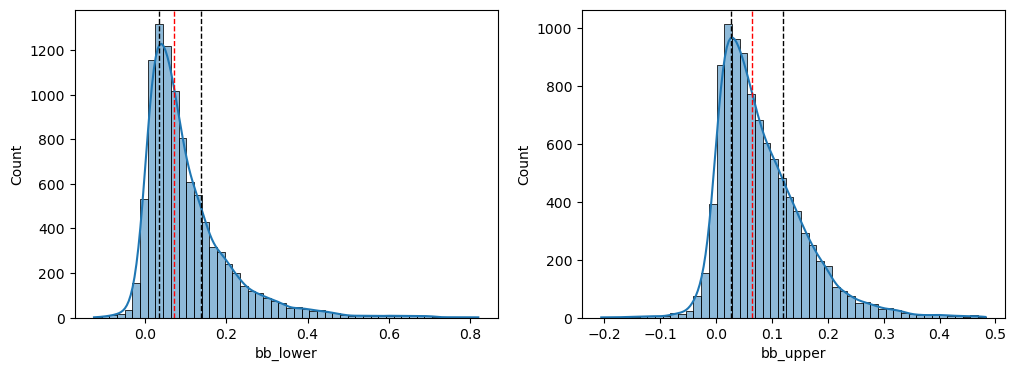

In [149]:
# Bolinger bands
def draw_ax(df, feat, ax):
  print("Skew", feat, ":", df[feat].skew())
  sns.histplot(df[feat].dropna(), bins=50, kde=True, ax=ax)
  q1, mean, q3 = df[feat].quantile([0.25, 0.50, 0.75])
  ax.axvline(q1, ls="--", lw=1, c="k")
  ax.axvline(mean, ls="--", lw=1, c="r")
  ax.axvline(q3, ls="--", lw=1, c="k")

_, axes = plt.subplots(1, 2, figsize=(12, 4))

draw_ax(main_df, "bb_lower", axes[0])
draw_ax(main_df, "bb_upper", axes[1])

# Observations
# All bollinger bands have a severe right skew. 

# Checking using log1p


Skew bb_lower : 1.659147206141382
Skew bb_upper : 0.9498067989824238


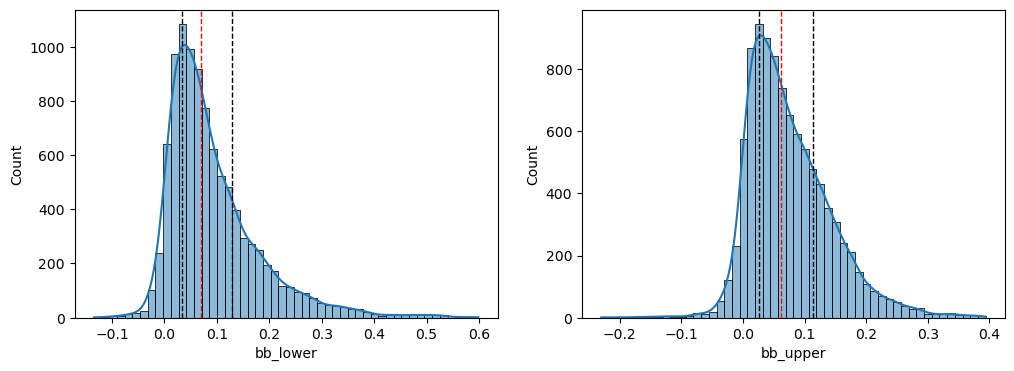

In [150]:
logpbb_df = main_df[["bb_lower", "bb_upper"]].copy()
logpbb_df["bb_lower"] = np.log1p(logpbb_df["bb_lower"])
logpbb_df["bb_upper"] = np.log1p(logpbb_df["bb_upper"])


_, axes = plt.subplots(1, 2, figsize=(12, 4))
draw_ax(logpbb_df, "bb_lower", axes[0])
draw_ax(logpbb_df, "bb_upper", axes[1])

# Even though the distribution is far from normal, the skew is not as severe as without applying log1p.
# This transformation has to be applied in the pipeline


skew return_1d: 0.498834713876602
[[<Axes: > <Axes: >]
 [<Axes: > <Axes: >]]


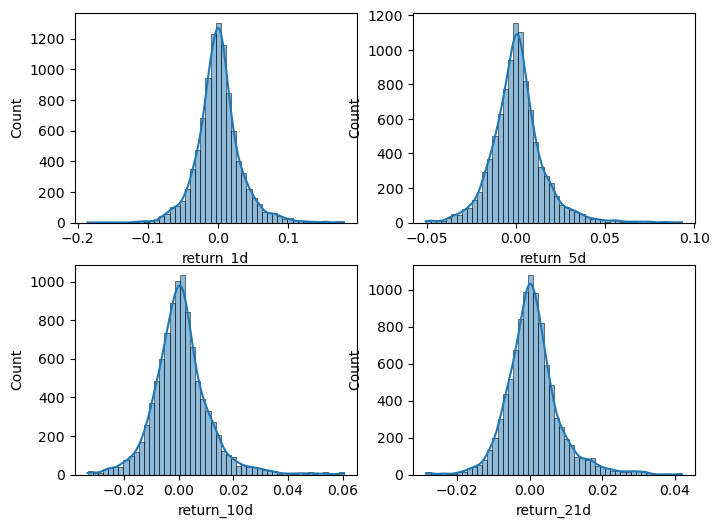

In [151]:
# Checking returns distribution
print("skew return_1d:", main_df["return_1d"].skew())
# Almost normal distribution. I slight right skew.
_, axes = plt.subplots(2, 2, figsize=(8, 6))
print(axes)

for i, d in enumerate([1, 5, 10, 21]):
  ai = int(i / 2)
  aj = i % 2
  sns.histplot(main_df[f"return_{d}d"].dropna(), bins=50, kde=True, ax=axes[ai, aj])

# As the delta t increases, the distributions becomes skewed. 
# This reflect the variance in the returns increases as time goes by. 
# Is is necessary to remember that the returns are computed as a compounded average factor per day, so the values are comparable across different lags. 



In [152]:
main_df[["sector", "target_return_1d"]].groupby("sector").describe().transpose()


sector                  Consumer Discretionary  Consumer Staples         ETF  \
target_return_1d count              970.000000        485.000000  481.000000   
                 mean                 0.000784          0.000719    0.000727   
                 std                  0.025599          0.012019    0.009878   
                 min                 -0.065637         -0.027580   -0.027490   
                 25%                 -0.014706         -0.006993   -0.004823   
                 50%                  0.000000          0.000000    0.000569   
                 75%                  0.015577          0.007692    0.006515   
                 max                  0.089371          0.030496    0.031387   

sector                       Energy   Financials  Information Technology  \
target_return_1d count  1603.000000  1517.000000             3151.000000   
                 mean      0.000987     0.000778                0.002000   
                 std       0.032812     0.040379                0.029689   
                 min      -0.107767    -0.111649               -0.119841   
                 25%      -0.019205    -0.022866               -0.013675   
                 50%       0.000000    -0.001905                0.001245   
                 75%       0.019153     0.019520                0.015942   
                 max       0.153160     0.179337                0.148919   

sector                   Materials   Utilities  
target_return_1d count  812.000000  831.000000  
                 mean    -0.000292    0.001056  
                 std      0.032117    0.032861  
                 min     -0.081642   -0.185646  
                 25%     -0.020351   -0.018500  
                 50%     -0.004115    0.000000  
                 75%      0.018888    0.018075  
                 max      0.106247    0.177866

In [153]:
main_df[["ticker", "target_return_1d"]].groupby("ticker").describe().sort_values(by=("target_return_1d", "max"), ascending=False).transpose()



ticker                       BBARD       CEPUD       BYMAD       SUPVD  \
target_return_1d count  335.000000  352.000000  352.000000  346.000000   
                 mean     0.000708    0.000492    0.001275   -0.000863   
                 std      0.045320    0.038208    0.036688    0.047229   
                 min     -0.103408   -0.185646   -0.111649   -0.094076   
                 25%     -0.026787   -0.023054   -0.016880   -0.032426   
                 50%     -0.004127    0.000000   -0.001116   -0.003553   
                 75%      0.026101    0.021712    0.017098    0.022757   
                 max      0.179337    0.177866    0.169799    0.153891   

ticker                       TGN4D       ORCLD         MUD        AMDD  \
target_return_1d count  314.000000  296.000000  430.000000  485.000000   
                 mean     0.000282    0.001045    0.006183    0.002668   
                 std      0.041928    0.040148    0.043603    0.034647   
                 min     -0.107767   -0.102110   -0.119841   -0.078581   
                 25%     -0.026016   -0.023335   -0.017743   -0.017621   
                 50%      0.000000    0.000000    0.002450    0.000000   
                 75%      0.022563    0.023785    0.031189    0.021739   
                 max      0.153160    0.148919    0.138652    0.112269   

ticker                       LOMAD       PAMPD       GGALD       TGSUD  \
target_return_1d count  327.000000  479.000000  484.000000  317.000000   
                 mean     0.000276    0.001470    0.001637    0.000500   
                 std      0.034274    0.028330    0.033511    0.032767   
                 min     -0.081642   -0.073456   -0.078463   -0.084453   
                 25%     -0.022541   -0.015927   -0.018985   -0.020652   
                 50%     -0.002907    0.000000    0.000000   -0.001631   
                 75%      0.020101    0.015425    0.017291    0.020295   
                 max      0.106247    0.102993    0.102078    0.101110   

ticker                       TXARD       YPFDD       BABAD        IBMD  \
target_return_1d count  485.000000  486.000000  485.000000  485.000000   
                 mean    -0.000674    0.001999    0.001060    0.001358   
                 std      0.030607    0.029274    0.028170    0.023710   
                 min     -0.081616   -0.068614   -0.065637   -0.066676   
                 25%     -0.019672   -0.016037   -0.016647   -0.012987   
                 50%     -0.004255    0.001382   -0.002320    0.001459   
                 75%      0.018382    0.017297    0.018107    0.012739   
                 max      0.092857    0.089445    0.089371    0.086332   

ticker                       VISTD       NVDAD       MELID       GOGLD  \
target_return_1d count  486.000000  486.000000  485.000000  484.000000   
                 mean     0.000748    0.001305    0.000507    0.001589   
                 std      0.029386    0.026127    0.022766    0.018356   
                 min     -0.075129   -0.074494   -0.061400   -0.048378   
                 25%     -0.015383   -0.013484   -0.012410   -0.009780   
                 50%      0.000000    0.002035    0.000000    0.001576   
                 75%      0.018084    0.016656    0.014675    0.012556   
                 max      0.082264    0.080264    0.058925    0.050945   

ticker                       MSFTD        SPYD         KOD  
target_return_1d count  485.000000  481.000000  485.000000  
                 mean    -0.000043    0.000727    0.000719  
                 std      0.016261    0.009878    0.012019  
                 min     -0.039129   -0.027490   -0.027580  
                 25%     -0.009169   -0.004823   -0.006993  
                 50%      0.000000    0.000569    0.000000  
                 75%      0.010118    0.006515    0.007692  
                 max      0.041346    0.031387    0.030496

### Returns By Sector

In [154]:


# Returns by sector
target_cols_p = [1, 5, 10, 21]
target_cols = [f"target_return_{x}d" for x in target_cols_p]

ddf = main_df.groupby("sector")[target_cols].agg("mean").reset_index()
ddf["max_days"] = ddf[target_cols].idxmax(axis=1)
ddf["max"] = ddf[target_cols].max(axis=1)
ddf["total"] = ddf[target_cols].sum(axis=1)
ddf.sort_values(by="total", ascending=False)



,sector,target_return_1d,target_return_5d,target_return_10d,target_return_21d,max_days,max,total
5,Information Technology,0.002000,0.001740,0.001659,0.001665,target_return_1d,0.002000,0.007064
7,Utilities,0.001056,0.000718,0.000746,0.000823,target_return_1d,0.001056,0.003343
3,Energy,0.000987,0.000789,0.000871,0.000646,target_return_1d,0.000987,0.003293
2,ETF,0.000727,0.000751,0.000715,0.000765,target_return_21d,0.000765,0.002957
1,Consumer Staples,0.000719,0.000717,0.000683,0.000683,target_return_1d,0.000719,0.002802
0,Consumer Discretionary,0.000784,0.000606,0.000587,0.000619,target_return_1d,0.000784,0.002596
4,Financials,0.000778,0.000325,0.000411,0.000409,target_return_1d,0.000778,0.001922
6,Materials,-0.000292,-0.000528,-0.000498,-0.000453,target_return_1d,-0.000292,-0.001770


## Returns by Ticker

In [155]:
# Returns by Ticker
target_cols_p = [1, 5, 10, 21]
target_cols = [f"target_return_{x}d" for x in target_cols_p]

ddf = main_df.groupby("ticker")[target_cols].agg("mean").reset_index()
ddf["max"] = ddf[target_cols].max(axis=1)
ddf["max_days"] = ddf[target_cols].idxmax(axis=1)
ddf.sort_values(by="max", ascending=False)

,ticker,target_return_1d,target_return_5d,target_return_10d,target_return_21d,max,max_days
12,MUD,0.006183,0.005446,0.005331,0.005038,0.006183,target_return_1d
0,AMDD,0.002668,0.002500,0.002549,0.002627,0.002668,target_return_1d
22,YPFDD,0.001999,0.001701,0.001829,0.000767,0.001999,target_return_1d
5,GGALD,0.001637,0.001373,0.001456,0.001349,0.001637,target_return_1d
6,GOGLD,0.001589,0.001500,0.001511,0.001586,0.001589,target_return_1d
15,PAMPD,0.001470,0.001205,0.001231,0.001259,0.001470,target_return_1d
7,IBMD,0.001358,0.001132,0.000778,0.000688,0.001358,target_return_1d
13,NVDAD,0.001305,0.001153,0.001171,0.001317,0.001317,target_return_21d
3,BYMAD,0.001275,0.000571,0.000691,0.000831,0.001275,target_return_1d
1,BABAD,0.001060,0.000970,0.000919,0.001004,0.001060,target_return_1d


## RSI

In [156]:
# RSI

rsisig_df = main_df.copy()
rsisig_df["rsi_signal"] = pd.cut(main_df["rsi_14"], bins=[0, 30, 70, 100])#, labels=["oversold", "ok", "overbought"])
#rsisig_df
rsisig_df.groupby("rsi_signal")["target_return_5d"].describe()
# rsisig_df.groupby("rsi_signal")["target_5d"]


,count,mean,std,min,25%,50%,75%,max
rsi_signal,,,,,,,,
"(0, 30]",231.0,0.007504,0.022255,-0.048320,-0.005230,0.005013,0.020475,0.080806
"(30, 70]",8816.0,0.000571,0.014393,-0.050552,-0.007413,0.000000,0.007291,0.093172
"(70, 100]",803.0,0.002414,0.013896,-0.037132,-0.005017,0.001385,0.008405,0.060563


# Processing

## Categories

In [157]:
# date_str is to make easy to interpret data, so it will be dropped. 
# But before, the features "year" and "month" are crated so that it is possible to capture seasonal effects
main_df["year"] = main_df["date_str"].map(lambda x: int(x.split("-")[0]))
main_df["month"] = main_df["date_str"].map(lambda x: int(x.split("-")[1]))


# Checking 
main_df[["date", "date_str", "year", "month"]][100:200].head(10).sort_values(by="date", ascending=False)


,date,date_str,year,month
235,1734307200,2024-12-15,2024,12
234,1734048000,2024-12-12,2024,12
233,1733961600,2024-12-11,2024,12
232,1733875200,2024-12-10,2024,12
231,1733788800,2024-12-09,2024,12
230,1733702400,2024-12-08,2024,12
229,1733443200,2024-12-05,2024,12
228,1733356800,2024-12-04,2024,12
227,1733270400,2024-12-03,2024,12
226,1733184000,2024-12-02,2024,12


In [158]:
main_df.drop(columns=["date_str"]).head()

,ticker,date,open,high,low,close,volume,rsi_14,sma_20,ema_100,macd,MACD_signal,bb_upper,bb_lower,atr,return_1d,return_5d,return_10d,return_21d,return_42d,return_63d,return_1p_1d,return_1p_5d,return_1p_10d,return_1p_21d,return_2p_1d,return_2p_5d,return_2p_10d,return_2p_21d,return_3p_1d,return_3p_5d,return_3p_10d,return_3p_21d,return_4p_1d,return_4p_5d,return_4p_10d,return_4p_21d,return_5p_1d,return_5p_5d,return_5p_10d,return_5p_21d,target_return_1d,target_return_5d,target_return_10d,target_return_21d,country,asset_type,sector,year,month
126,AMDD,1720742400,18.299999,18.799999,18.250000,18.500000,2365,64.265903,16.7850,17.445716,0.373328,0.096642,0.000969,0.186375,0.807629,0.005435,0.018860,0.013052,0.002923,0.003463,0.000435,-0.008086,0.007278,-0.003914,0.004002,0.033426,0.003106,-0.001758,-0.005593,0.025714,-0.010885,0.010461,-0.009187,0.038576,0.001188,-0.005325,0.009540,0.018127,-0.004695,-0.009016,0.011771,-0.018919,-0.035391,-0.025301,-0.012154,United States,CEDEAR,Information Technology,2024,7
127,AMDD,1721001600,18.549999,18.799999,18.000000,18.150000,2088,59.989157,16.8825,17.459662,0.398962,0.157106,0.028924,0.169455,0.807084,-0.018919,0.007321,0.009271,0.003404,0.003231,0.000132,0.005435,0.011226,0.002140,0.003059,-0.008086,0.006782,-0.011574,-0.006039,0.033426,-0.002481,0.014242,-0.007873,0.025714,-0.003663,-0.004927,0.007935,0.038576,-0.019421,-0.004981,0.012733,-0.019284,-0.016514,-0.025301,-0.011785,United States,CEDEAR,Information Technology,2024,7
128,AMDD,1721088000,18.000000,18.299999,17.049999,17.799999,1875,55.977438,16.9475,17.466402,0.386579,0.203001,0.052642,0.151354,0.838721,-0.019284,-0.001677,0.011352,0.004495,0.003300,0.000315,-0.018919,0.024551,-0.003697,0.002106,0.005435,-0.006778,-0.006715,-0.005627,-0.008086,-0.000607,0.004948,-0.010543,0.033426,-0.007118,-0.000889,0.008500,0.025714,-0.006311,0.000592,0.011682,-0.075843,-0.026040,-0.025301,-0.011202,United States,CEDEAR,Information Technology,2024,7
129,AMDD,1721174400,17.200001,17.200001,16.200001,16.450001,3035,43.808218,16.9525,17.446275,0.264779,0.215356,0.124446,0.081040,0.893098,-0.075843,-0.023742,-0.001507,-0.000145,0.000960,-0.001340,-0.019284,0.021235,0.002120,0.002066,-0.018919,0.007345,-0.009568,-0.005925,0.005435,-0.003077,0.005437,-0.010411,-0.008086,-0.008930,0.000884,0.008548,0.033426,-0.010206,-0.001758,0.012224,-0.039514,-0.021580,-0.012879,-0.004861,United States,CEDEAR,Information Technology,2024,7
130,AMDD,1721260800,16.299999,16.500000,15.400000,15.800000,2607,39.370260,16.9175,17.413676,0.114483,0.195182,0.160112,0.049180,0.907876,-0.039514,-0.030009,-0.004627,-0.001628,-0.001460,-0.001575,-0.075843,0.021419,0.000303,-0.001292,-0.019284,0.008046,-0.005011,-0.001806,-0.018919,-0.007381,0.001160,-0.009670,0.005435,-0.010566,0.007280,0.007875,-0.008086,0.000576,-0.001862,0.005279,-0.022152,-0.023204,-0.015974,-0.002789,United States,CEDEAR,Information Technology,2024,7


In [159]:
# Checking categories. Number features are not categorical
main_df = main_df.drop(columns=["date_str"])
cat_cols = main_df.select_dtypes(include=["object", "str"]).columns.tolist()
cat_cols

['ticker', 'country', 'asset_type', 'sector']

In [160]:
# Encode month as cyclical or OHE ?

In [161]:
dummies_df = pd.get_dummies(main_df[cat_cols], drop_first=True, dtype="int8")
dummies_df.head()
# It is not the best encoding but it just to evaluate the model
# Maybe Target Enconding for tickers...

,ticker_BABAD,ticker_BBARD,ticker_BYMAD,ticker_CEPUD,ticker_GGALD,ticker_GOGLD,ticker_IBMD,ticker_KOD,ticker_LOMAD,ticker_MELID,ticker_MSFTD,ticker_MUD,ticker_NVDAD,ticker_ORCLD,ticker_PAMPD,ticker_SPYD,ticker_SUPVD,ticker_TGN4D,ticker_TGSUD,ticker_TXARD,ticker_VISTD,ticker_YPFDD,country_China,country_United States,asset_type_ETF,asset_type_Stock,sector_Consumer Staples,sector_ETF,sector_Energy,sector_Financials,sector_Information Technology,sector_Materials,sector_Utilities
126,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
127,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
128,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
129,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0
130,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0


# Evaluating

## Helpers

### Plotting

In [162]:
# Original source: ML for algo trading (Stefan Jansen)
def plot_pred_vs_actual(df, same_scale=True, ticker=None):
  lowx = None
  hix = None
  lowy = None
  hiy = None
  if same_scale:
    lowx = min(df["predicted"].min(), df["actual"].min())
    hix = max(df["predicted"].max(), df["actual"].max()) 
    lowy = lowx
    hiy = hix
  else:
    lowx = df["predicted"].min()
    hix = df["predicted"].max()
    lowy = df["actual"].min()
    hiy = df["actual"].max()
  if ticker is not None:
    idx = pd.IndexSlice
    df = df.loc[idx[ticker, :], :]
  j = sns.jointplot(x='predicted', y='actual',
                    robust=True, ci=None,
                    line_kws={'lw': 1, 'color': 'k'},
                    scatter_kws={'s': 1},
                    xlim=(lowx, hix),
                    ylim=(lowy, hiy),
                    #height=5,
                    #ratio=1,
                    data=df,
                    kind='reg')
  j.ax_joint.yaxis.set_major_formatter(
    FuncFormatter(lambda y, _: '{:.1%}'.format(y)))
  j.ax_joint.xaxis.set_major_formatter(
    FuncFormatter(lambda x, _: '{:.1%}'.format(x)))
  j.ax_joint.set_xlabel('Predicted')
  j.ax_joint.set_ylabel('Actuals')
  plt.tight_layout()

In [163]:
# Original source: ML for algo trading (Stefan Jansen)
def plot_ic_dist(df, ax=None):

  plt.figure(figsize=(5, 3))
  if ax is not None:
    sns.histplot(df.ic, ax=ax)
  else:
    ax = sns.histplot(df["ic"], stat="density", kde=True)
    mean, median = df["ic"].mean(), df["ic"].median()
    ax.axvline(0, lw=1, ls='--', c='k')
    ax.text(x=.05, y=.9,
            s=f'Mean: {mean:8.2f}\nMedian: {median:5.2f}',
            horizontalalignment='left',
            verticalalignment='center',
            transform=ax.transAxes)
    ax.set_xlabel('Information Coefficient')
  sns.despine()
  plt.tight_layout()

In [188]:
# Original source: ML for algo trading (Stefan Jansen)
def plot_rolling_ic(df):
    fig, axes = plt.subplots(nrows=2, sharex=True, figsize=(12, 6))
    rolling_result = df.sort_index().rolling(21).mean().dropna()
    rolling_result.index = pd.to_datetime(rolling_result.index.get_level_values("date"), unit="s")
    mean_ic = df["ic"].mean()
    rolling_result["ic"].plot(ax=axes[0],
                              x=df.index.get_level_values("date"),
                           title=f'Information Coefficient (Mean: {mean_ic:.2f})',
                           lw=1)
    axes[0].axhline(0, lw=.5, ls='-', color='k')
    axes[0].axhline(mean_ic, lw=1, ls='--', color='k')

    mean_rmse = df["rmse"].mean()
    rolling_result["rmse"].plot(ax=axes[1],
                             title=f'Root Mean Squared Error (Mean: {mean_rmse:.2%})',
                             lw=1,
                             ylim=(0, df["rmse"].max()))
    axes[1].axhline(df["rmse"].mean(), lw=1, ls='--', color='k')

    sns.despine()
    plt.tight_layout()

### Pipeline

In [248]:

# Removing "date_str" and to have a baseline just encode using simple One Hot Encoding.
# To avoid data leakage, a simple pipeline will be created using a function
def get_log1p_transf():
  return FunctionTransformer(
    func=np.log1p,
    inverse_func=np.expm1,
    validate=False,
    feature_names_out="one-to-one",
  )

def create_preprocess_pipeline(cat_cols=None):
  # This steps can be executed in parallel
  col_t001 = ColumnTransformer(
    transformers=[
      ("log1p", get_log1p_transf(), ["bb_lower", "bb_upper"]),
      # To be able to create an dataframe as output
      # To avoid the column warning in FunctionTrasformer
      ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_cols),
    ],
    remainder="passthrough"
  )

  return Pipeline(
    [
      ("col_t001", col_t001),
    ]
  )

def add_model(pipeline, model):
  steps = pipeline.steps
  steps.append(("model", model))
  return Pipeline(steps=steps)

In [166]:
# The idea is predict returns for several periods. As checked before, the daily returns increases as the time period increases.
return_cols = ["target_return_1d", "target_return_5d", "target_return_10d", "target_return_21d"]
target_return_col = "target_return_5d"
y = main_df[target_return_col]
X = main_df.drop(columns=[col for col in return_cols])
X = pd.get_dummies(X, columns=cat_cols, drop_first=True, dtype="int8")
X.head().join(y).head()



,date,open,high,low,close,volume,rsi_14,sma_20,ema_100,macd,MACD_signal,bb_upper,bb_lower,atr,return_1d,return_5d,return_10d,return_21d,return_42d,return_63d,return_1p_1d,return_1p_5d,return_1p_10d,return_1p_21d,return_2p_1d,return_2p_5d,return_2p_10d,return_2p_21d,return_3p_1d,return_3p_5d,return_3p_10d,return_3p_21d,return_4p_1d,return_4p_5d,return_4p_10d,return_4p_21d,return_5p_1d,return_5p_5d,return_5p_10d,return_5p_21d,year,month,ticker_BABAD,ticker_BBARD,ticker_BYMAD,ticker_CEPUD,ticker_GGALD,ticker_GOGLD,ticker_IBMD,ticker_KOD,ticker_LOMAD,ticker_MELID,ticker_MSFTD,ticker_MUD,ticker_NVDAD,ticker_ORCLD,ticker_PAMPD,ticker_SPYD,ticker_SUPVD,ticker_TGN4D,ticker_TGSUD,ticker_TXARD,ticker_VISTD,ticker_YPFDD,country_China,country_United States,asset_type_ETF,asset_type_Stock,sector_Consumer Staples,sector_ETF,sector_Energy,sector_Financials,sector_Information Technology,sector_Materials,sector_Utilities,target_return_5d
126,1720742400,18.299999,18.799999,18.250000,18.500000,2365,64.265903,16.7850,17.445716,0.373328,0.096642,0.000969,0.186375,0.807629,0.005435,0.018860,0.013052,0.002923,0.003463,0.000435,-0.008086,0.007278,-0.003914,0.004002,0.033426,0.003106,-0.001758,-0.005593,0.025714,-0.010885,0.010461,-0.009187,0.038576,0.001188,-0.005325,0.009540,0.018127,-0.004695,-0.009016,0.011771,2024,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.035391
127,1721001600,18.549999,18.799999,18.000000,18.150000,2088,59.989157,16.8825,17.459662,0.398962,0.157106,0.028924,0.169455,0.807084,-0.018919,0.007321,0.009271,0.003404,0.003231,0.000132,0.005435,0.011226,0.002140,0.003059,-0.008086,0.006782,-0.011574,-0.006039,0.033426,-0.002481,0.014242,-0.007873,0.025714,-0.003663,-0.004927,0.007935,0.038576,-0.019421,-0.004981,0.012733,2024,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.016514
128,1721088000,18.000000,18.299999,17.049999,17.799999,1875,55.977438,16.9475,17.466402,0.386579,0.203001,0.052642,0.151354,0.838721,-0.019284,-0.001677,0.011352,0.004495,0.003300,0.000315,-0.018919,0.024551,-0.003697,0.002106,0.005435,-0.006778,-0.006715,-0.005627,-0.008086,-0.000607,0.004948,-0.010543,0.033426,-0.007118,-0.000889,0.008500,0.025714,-0.006311,0.000592,0.011682,2024,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.026040
129,1721174400,17.200001,17.200001,16.200001,16.450001,3035,43.808218,16.9525,17.446275,0.264779,0.215356,0.124446,0.081040,0.893098,-0.075843,-0.023742,-0.001507,-0.000145,0.000960,-0.001340,-0.019284,0.021235,0.002120,0.002066,-0.018919,0.007345,-0.009568,-0.005925,0.005435,-0.003077,0.005437,-0.010411,-0.008086,-0.008930,0.000884,0.008548,0.033426,-0.010206,-0.001758,0.012224,2024,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.021580
130,1721260800,16.299999,16.500000,15.400000,15.800000,2607,39.370260,16.9175,17.413676,0.114483,0.195182,0.160112,0.049180,0.907876,-0.039514,-0.030009,-0.004627,-0.001628,-0.001460,-0.001575,-0.075843,0.021419,0.000303,-0.001292,-0.019284,0.008046,-0.005011,-0.001806,-0.018919,-0.007381,0.001160,-0.009670,0.005435,-0.010566,0.007280,0.007875,-0.008086,0.000576,-0.001862,0.005279,2024,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,-0.023204


In [342]:
remove_cols = ["open", "high", "low", "close", "volume", "target_return_5d", "target_return_10d", "target_return_21d"]
for i in range(1, 6):
  for j in [1, 5, 10, 21]:
    remove_cols.append(f"return_{i}p_{j}d")

eval_df = main_df.drop(columns=g_remove_cols)
eval_df.info()

<class 'pandas.DataFrame'>
Index: 9850 entries, 126 to 13209
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   ticker            9850 non-null   str    
 1   date              9850 non-null   int64  
 2   rsi_14            9850 non-null   float64
 3   sma_20            9850 non-null   float64
 4   ema_100           9850 non-null   float64
 5   macd              9850 non-null   float64
 6   MACD_signal       9850 non-null   float64
 7   bb_upper          9850 non-null   float64
 8   bb_lower          9850 non-null   float64
 9   atr               9850 non-null   float64
 10  return_1d         9850 non-null   float64
 11  return_5d         9850 non-null   float64
 12  return_10d        9850 non-null   float64
 13  return_21d        9850 non-null   float64
 14  return_42d        9850 non-null   float64
 15  return_63d        9850 non-null   float64
 16  target_return_1d  9850 non-null   float64
 17  country 

In [167]:
# Checking OLS model

os_model = sm.OLS(y, sm.add_constant(X)).fit()
os_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:       target_return_5d   R-squared:                       0.075
Model:                            OLS   Adj. R-squared:                  0.069
Method:                 Least Squares   F-statistic:                     12.52
Date:                Wed, 12 Aug 2026   Prob (F-statistic):          2.33e-120
Time:                        12:41:05   Log-Likelihood:                 28019.
No. Observations:                9850   AIC:                        -5.591e+04
Df Residuals:                    9786   BIC:                        -5.545e+04
Df Model:                          63                                         
Covariance Type:            nonrobust                                         
=================================================================================================
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                           -75.1818      8.822     -8.522      0.000     -92.475     -57.889
date                          -1.592e-09   1.92e-10     -8.297      0.000   -1.97e-09   -1.22e-09
open                              0.0002      0.000      0.741      0.459      -0.000       0.001
high                              0.0003      0.000      1.007      0.314      -0.000       0.001
low                               0.0003      0.000      0.796      0.426      -0.000       0.001
close                            -0.0003      0.000     -0.810      0.418      -0.001       0.000
volume                         1.056e-08   2.61e-09      4.048      0.000    5.45e-09    1.57e-08
rsi_14                            0.0002   3.32e-05      5.248      0.000       0.000       0.000
sma_20                           -0.0006      0.000     -1.804      0.071      -0.001    5.08e-05
ema_100                          -0.0002      0.000     -0.829      0.407      -0.001       0.000
macd                             -0.0033      0.002     -1.959      0.050      -0.007    2.46e-06
MACD_signal                       0.0038      0.002      2.398      0.017       0.001       0.007
bb_upper                          0.0553      0.009      5.938      0.000       0.037       0.074
bb_lower                         -0.0417      0.008     -5.267      0.000      -0.057      -0.026
atr                               0.0008      0.001      0.967      0.333      -0.001       0.002
return_1d                        -0.0460      0.012     -3.785      0.000      -0.070      -0.022
return_5d                         0.0778      0.078      0.998      0.318      -0.075       0.231
return_10d                        0.8931      0.135      6.609      0.000       0.628       1.158
return_21d                        0.9112      0.315      2.897      0.004       0.295       1.528
return_42d                       -1.8844      0.795     -2.371      0.018      -3.442      -0.327
return_63d                       -0.2413      0.996     -0.242      0.809      -2.194       1.711
return_1p_1d                     -0.0627      0.012     -5.352      0.000      -0.086      -0.040
return_1p_5d                     -0.2578      0.059     -4.376      0.000      -0.373      -0.142
return_1p_10d                    -0.0607      0.121     -0.502      0.616      -0.298       0.176
return_1p_21d                     0.7914      0.313      2.525      0.012       0.177       1.406
return_2p_1d                     -0.0758      0.012     -6.516      0.000      -0.099      -0.053
return_2p_5d                      0.1870      0.060      3.098      0.002       0.069       0.305
return_2p_10d                     0.4313      0.116      3.729      0.000       0.205       0.658
return_2p_21d                     0.2706     

## Cross validation

In [168]:
# To determine the size of test set, first count the number of tickers available

ticker_count = main_df["ticker"].nunique()
print("ticker count:", ticker_count)
main_df["ticker"].unique()

ticker count: 23


<StringArray>
[ 'AMDD', 'BABAD', 'BBARD', 'BYMAD', 'CEPUD', 'GGALD', 'GOGLD',  'IBMD',
   'KOD', 'LOMAD', 'MELID', 'MSFTD',   'MUD', 'NVDAD', 'ORCLD', 'PAMPD',
  'SPYD', 'SUPVD', 'TGN4D', 'TGSUD', 'TXARD', 'VISTD', 'YPFDD']
Length: 23, dtype: str

In [169]:
main_df.groupby("ticker")["ticker"].agg("count")

ticker
AMDD     485
BABAD    485
BBARD    335
BYMAD    352
CEPUD    352
GGALD    484
GOGLD    484
IBMD     485
KOD      485
LOMAD    327
MELID    485
MSFTD    485
MUD      430
NVDAD    486
ORCLD    296
PAMPD    479
SPYD     481
SUPVD    346
TGN4D    314
TGSUD    317
TXARD    485
VISTD    486
YPFDD    486
Name: ticker, dtype: int64

In [170]:
YEAR_DAYS = 252
dfirst, dend = datetime.fromtimestamp(main_df["date"].min()), datetime.fromtimestamp(main_df["date"].max())
print("From:", dfirst.strftime("%Y-%m-%d"), "To:", dend.strftime("%Y-%m-%d"))
days = main_df["date"].unique()
print("Days count:", len(days))

From: 2024-07-10 To: 2026-07-02
Days count: 486


### MultipleTimeSeriesCV Func

In [171]:
# Do to not all the tickers have the same number of records, TimeSeriesSPlit is not usefull because
# It splits data based on record count.
# For that reason, MultipleTimeSeriesCV from "ML for Algorithmic" (Stefan Jansen) book will be used
# Because it split data based on date
# URL: https://github.com/stefan-jansen/machine-learning-for-trading/blob/second-edition/07_linear_models/05_predicting_stock_returns_with_linear_regression.ipynb
class MultipleTimeSeriesSplit:
  """Generates tuples of train_idx, test_idx pairs
    Assumes the MultiIndex contains levels 'symbol' and 'date'
    purges overlapping outcomes"""

  def __init__(self,
               n_splits=3,
               train_period_length=63,
               test_period_length=10,
               lookahead=None,
               shuffle=False):
    self.n_splits = n_splits
    self.lookahead = lookahead
    self.test_length = test_period_length
    self.train_length = train_period_length
    self.shuffle = shuffle

  def split(self, X, y=None, groups=None):
    unique_dates = X.index.get_level_values("date").unique()
    days = sorted(unique_dates, reverse=True)

    split_idx = []
    for i in range(self.n_splits):
      test_end_idx = i * self.test_length
      test_start_idx = test_end_idx + self.test_length
      train_end_idx = test_start_idx + self.lookahead - 1
      train_start_idx = train_end_idx + self.train_length + self.lookahead - 1
      if train_start_idx >= len(days):
        # Validating OOB error.
        break

      split_idx.append([train_start_idx, train_end_idx,
                        test_start_idx, test_end_idx])

    dates = X.reset_index()[["date"]]
    for train_start, train_end, test_start, test_end in split_idx:
      train_idx = dates[(dates["date"] > days[train_start])
        & (dates["date"] <= days[train_end])].index

      test_idx = dates[(dates["date"] > days[test_start])
        & (dates["date"] <= days[test_end])].index
      if self.shuffle:
        np.random.shuffle(list(train_idx))
      yield train_idx, test_idx


  def get_n_splits(self, X, y, groups=None):
    return self.n_splits


In [172]:
# Cheking  MultiTimeSeriesSplit
# It should output several train periods of 63 days followed by 10 days tests periods.
# Where test period date is always after the train period date.

def fmt_date(dt):
  tm = datetime.fromtimestamp(dt)
  return tm.strftime("%Y-%m-%d")

train_period_length = 63
test_period_length = 10
n_splits = int(2 * YEAR_DAYS / test_period_length)
lookahead =1 
print("n_splits:", n_splits)

cv = MultipleTimeSeriesSplit(n_splits=n_splits,
                          test_period_length=test_period_length,
                          lookahead=lookahead,
                          train_period_length=train_period_length)

cv_data_df = main_df.set_index(["ticker", "date"])

i = 0
for train_idx, test_idx in cv.split(X=cv_data_df):
    train = cv_data_df.iloc[train_idx]
    train_dates = train.index.get_level_values("date")
    test = cv_data_df.iloc[test_idx]
    test_dates = test.index.get_level_values("date")
    df = pd.concat([train.reset_index(), test.reset_index()])
    n = len(df)
    assert n== len(df.drop_duplicates())
    print(train.groupby(level='ticker').size().value_counts().index[0], "train days", 
          "(from", fmt_date(train_dates.min()), "to", fmt_date(train_dates.max()),
          ") --->", test.groupby(level='ticker').size().value_counts().index[0],
          "test days (from", fmt_date(test_dates.min()), "to", fmt_date(test_dates.max()), ")")
    i += 1
    if i == 10:
        break

n_splits: 50
63 train days (from 2026-03-16 to 2026-06-18 ) ---> 10 test days (from 2026-06-21 to 2026-07-02 )
63 train days (from 2026-03-02 to 2026-06-03 ) ---> 10 test days (from 2026-06-04 to 2026-06-18 )
63 train days (from 2026-02-12 to 2026-05-19 ) ---> 10 test days (from 2026-05-20 to 2026-06-03 )
63 train days (from 2026-01-29 to 2026-05-05 ) ---> 10 test days (from 2026-05-06 to 2026-05-19 )
63 train days (from 2026-01-15 to 2026-04-20 ) ---> 10 test days (from 2026-04-21 to 2026-05-05 )
63 train days (from 2026-01-01 to 2026-04-06 ) ---> 10 test days (from 2026-04-07 to 2026-04-20 )
63 train days (from 2025-12-15 to 2026-03-18 ) ---> 10 test days (from 2026-03-19 to 2026-04-06 )
63 train days (from 2025-11-30 to 2026-03-04 ) ---> 10 test days (from 2026-03-05 to 2026-03-18 )
63 train days (from 2025-11-13 to 2026-02-18 ) ---> 10 test days (from 2026-02-19 to 2026-03-04 )
63 train days (from 2025-10-30 to 2026-02-02 ) ---> 10 test days (from 2026-02-03 to 2026-02-18 )


# Model Evaluation

In [356]:
def get_data_for_model(df):
  X = df.copy()
  # Setting as index makes the model ignore the data for training
  # That way, a general market behavior approach is learned and not a specific ticker behavior. 
  X = X.set_index(["ticker", "date"])
  # Forward return are the target, so they are removed from the features.
  X = X.drop(columns=[c for c in df.columns if "lag" in c])
  # Removing columns that are not needed for training. They are used for EDA and analysis but not for training the model
  # Remaining columns are built base on close mainly
  remove_cols = ["open", "high", "low", "close", "volume", "target_return_5d", "target_return_10d", "target_return_21d"]
  for i in range(1, 6):
    for j in [1, 5, 10, 21]:
      remove_cols.append(f"return_{i}p_{j}d")

  # For now, only predicting 1 day returns. The other forward returns will be used in future iterations.
  for j in [5, 10, 21]:
      remove_cols.append(f"target_return_{j}d")

  remove_cols.append("sma_20")
  remove_cols.append("ema_100")
  X = X.drop(columns=remove_cols)
  y = X.pop("target_return_1d")
  return X, y

In [357]:
tX, y = get_data_for_model(main_df)
tX.info()

<class 'pandas.DataFrame'>
MultiIndex: 9850 entries, ('AMDD', np.int64(1720742400)) to ('YPFDD', np.int64(1783036800))
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   rsi_14       9850 non-null   float64
 1   macd         9850 non-null   float64
 2   MACD_signal  9850 non-null   float64
 3   bb_upper     9850 non-null   float64
 4   bb_lower     9850 non-null   float64
 5   atr          9850 non-null   float64
 6   return_1d    9850 non-null   float64
 7   return_5d    9850 non-null   float64
 8   return_10d   9850 non-null   float64
 9   return_21d   9850 non-null   float64
 10  return_42d   9850 non-null   float64
 11  return_63d   9850 non-null   float64
 12  country      9850 non-null   str    
 13  asset_type   9850 non-null   str    
 14  sector       9850 non-null   str    
 15  year         9850 non-null   int64  
 16  month        9850 non-null   int64  
dtypes: float64(12), int64(2), str(3)
memory usage

## Helpers

### Evaluation function

In [328]:
def print_results(results):
    res_df = pd.DataFrame(results)
    print("Results summary:")
    print("RMSE mean:", res_df["rmse"].mean(), "var:", res_df["rmse"].var())

def eval(X, y, pip, train_period_lenght=63, test_period_lenght=10, lookahead=1):
  total_days = X.index.get_level_values("date").nunique()
  n_splits = int(total_days / test_period_length)
  cat_cols = X.select_dtypes(include=["object", "str"]).columns.tolist()
  cv = MultipleTimeSeriesSplit(n_splits=n_splits,
                               test_period_length=test_period_length,
                               lookahead=lookahead,
                               train_period_length=train_period_length) 
  actuals = []
  preds = []
  scores = []
  coefs = []

  for train_idx, test_idx in cv.split(X=X):
    X_train = X.iloc[train_idx]
    y_train = y.iloc[train_idx]
    X_test = X.iloc[test_idx]
    y_test = y.iloc[test_idx]
    pip.fit(X_train, y_train)
    y_pred = pip.predict(X_test)
    curr_preds = y_test.to_frame("actual").assign(predicted=y_pred)
    preds_by_day = curr_preds.groupby(level="date")
    # spearmanr returns F-statitics and p-value
    curr_ic = preds_by_day.apply(lambda x: spearmanr(x["predicted"], 
                                                x["actual"])[0] * 100)
    curr_rmse = preds_by_day.apply(lambda x: np.sqrt(mean_squared_error(x["actual"], x["predicted"])))
    curr_scores = pd.concat([curr_ic, curr_rmse], axis=1).rename(columns={0: "ic", 1: "rmse"})
    preds.append(curr_preds)
    scores.append(curr_scores)
    model = pip.named_steps["model"]
    if hasattr(model, "coef_"):
      coefs.append(model.coef_)
  return {
    "predictions": preds,
    "scores": scores,
    "coefs": coefs,
  }

## Eval Linear Regression

In [195]:
Xp, yp = get_data_for_model(main_df)
Xp.index.get_level_values("date").nunique()


486

In [358]:
# Evalulate Linear Regression
X, y = get_data_for_model(main_df)
pip = create_preprocess_pipeline(cat_cols=cat_cols)
pip = add_model(pip, LinearRegression())
ln_res = eval(X, y, pip)
ln_scores = ln_res["scores"]
ln_preds = ln_res["predictions"]

pd.concat(preds).head()

actual  predicted
ticker date                           
AMDD   1782086400 -0.056537   0.010020
       1782172800 -0.007491  -0.003800
       1782259200  0.026415   0.000399
       1782345600 -0.023897  -0.012551
       1782432000  0.037665  -0.006307

In [359]:
#pd.concat(scores).head().apply(lambda x: datetime.fromtimestamp(x.index["date"]))
all_ln_scores = pd.concat(ln_scores)
all_ln_scores = all_ln_scores.sort_index(level="date")
all_ln_scores["date_str"] = all_ln_scores.index.get_level_values("date").map(lambda x: datetime.fromtimestamp(x).strftime("%Y-%m-%d"))
pd.concat([all_ln_scores.head(), all_ln_scores.tail()])


,ic,rmse,date_str
date,,,
1728864000,11.785714,0.031890,2024-10-13
1728950400,29.311897,0.024974,2024-10-14
1729036800,-21.428571,0.023364,2024-10-15
1729123200,65.594307,0.015094,2024-10-16
1729209600,20.000000,0.020154,2024-10-17
1782691200,-2.879729,0.023627,2026-06-28
1782777600,-16.770186,0.036033,2026-06-29
1782864000,-34.726143,0.031874,2026-06-30
1782950400,23.433089,0.015512,2026-07-01


### Prediction vs Actual Scatter Plot

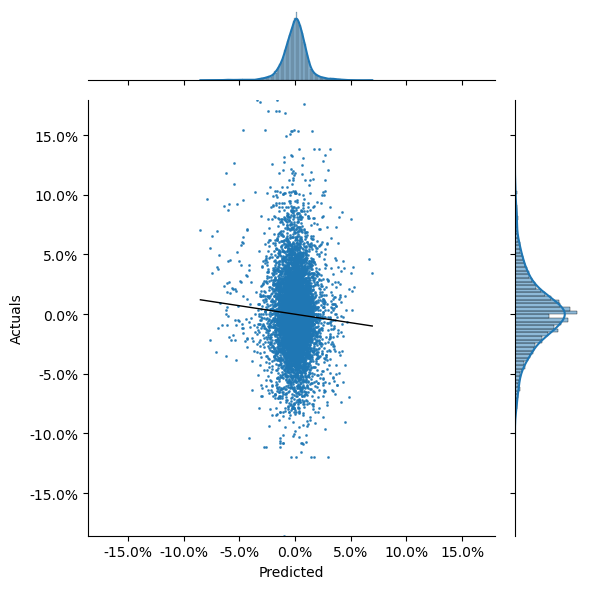

In [360]:
all_ln_preds = pd.concat(ln_preds)
plot_pred_vs_actual(all_ln_preds, same_scale=True)

#### Observations:

- The model should look more like a diagonal line with positive slop and it has a vertical cloud shape. This indicates that the predicte power is very low
- The slope is negative, that indicates that could have and inverse actuals / predicted relationship
- The vertical cloud shape indicates that the predicted values are very close to 0. This means that the model is not capturing volatility on returns.
- The previous point from the scatter is confirmed by the distribution graph, where the predicted plot is very pointy and the values are no as spread as in the actual distribution plot, where the values are more spread and the distribution is more flat.
- There are many real value outliers predicted as close to 0 values. This reinforces the idea that the model is not caputuring volatility. The model is not able to predict extreme values at all.

### IC distribution

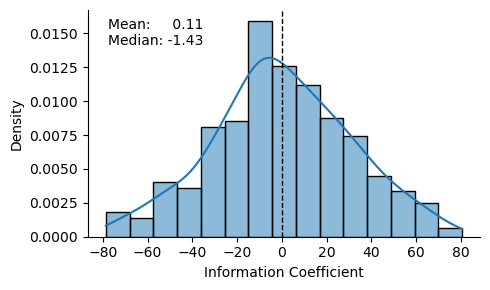

In [253]:
plot_ic_dist(all_ln_scores)

### Rolling IC

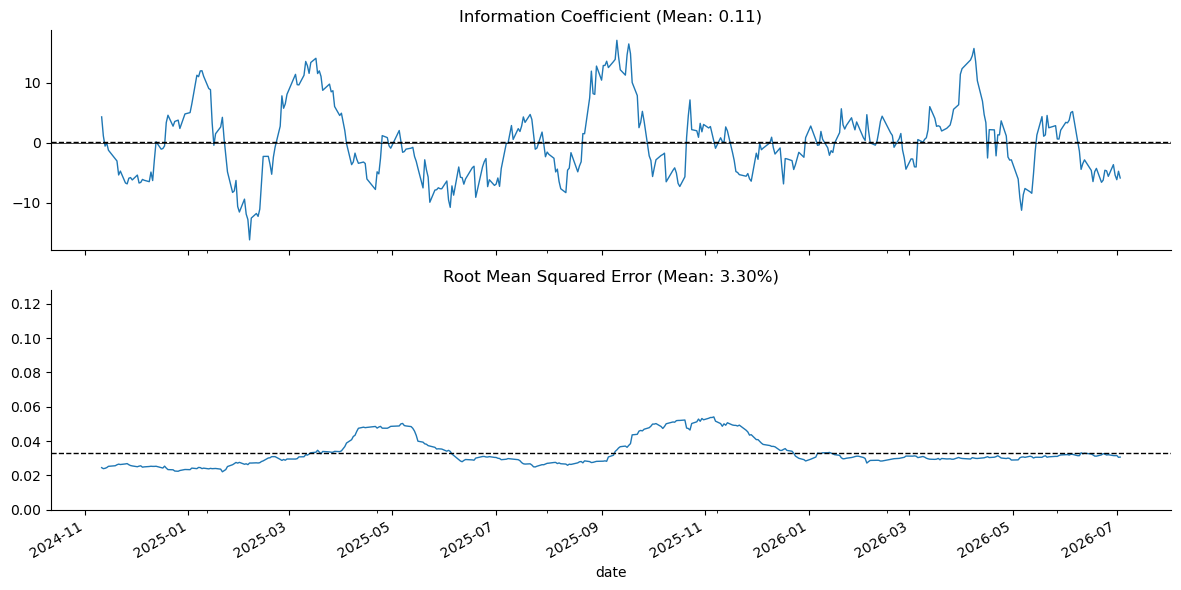

In [254]:
plot_rolling_ic(all_ln_scores.drop(columns=["date_str"]))

## Evaluate Ridge

In [319]:
# Evalulate Rigde
# TODO: Use optuna to eval several models
rd_alphas = np.logspace(-2, 1, 10)
rd_scores = []
rd_preds = []
rd_coefs = []
for alpha in rd_alphas:
  model = Ridge(alpha=alpha)
  X, y = get_data_for_model(main_df)
  pip = create_preprocess_pipeline(cat_cols=cat_cols)
  pip = add_model(pip, model)
  rd_res = eval(X, y, pip)
  rd_scores.append({"alpha": alpha, "scores": rd_res["scores"]})
  rd_preds.append({"alpha": alpha, "predictions": rd_res["predictions"]})
  rd_coefs.append({"alpha": alpha, "coefs": rd_res["coefs"]})


pd.concat(rd_preds[0]["predictions"]).head()

actual  predicted
ticker date                           
AMDD   1782086400 -0.056537   0.006315
       1782172800 -0.007491  -0.001968
       1782259200  0.026415   0.002604
       1782345600 -0.023897  -0.013478
       1782432000  0.037665  -0.006532

In [449]:
rdby_alpha = pd.DataFrame()
for it in rd_scores:
  df = pd.concat(it["scores"])
  df["alpha"] = it["alpha"]
  df = df.groupby("date").agg("mean").reset_index(drop=True)
  df = df.groupby("alpha").agg("mean").reset_index()
  rdby_alpha = pd.concat([rdby_alpha, df])

rdby_alpha.sort_values(by="ic", ascending=False).reset_index(drop=True)



,alpha,ic,rmse
0,0.010000,0.715335,0.031838
1,0.021544,0.461239,0.031619
2,10.000000,0.344988,0.029794
3,1.000000,0.292143,0.030195
4,2.154435,0.246310,0.030003
5,0.046416,0.228403,0.031343
6,0.100000,0.214193,0.031036
7,0.215443,0.191762,0.030728
8,4.641589,0.128194,0.029875
9,0.464159,0.010602,0.030442


In [452]:

ic_df = pd.DataFrame()
for pred in rd_preds:
  alpha_df = pd.concat(pred["predictions"])
  #alpha_df = alpha_df.drop(columns=["ticker"])
  alpha_df["alpha"] = pred["alpha"]
  alpha_df["ic"] = alpha_df.reset_index().groupby("date").apply(lambda x: spearmanr(x["predicted"], x["actual"])[0] * 100)
  ic_df = pd.concat([ic_df, alpha_df[["alpha", "ic"]].reset_index(drop=True)])

ic_df = ic_df.groupby("alpha").agg("mean").sort_values(by="ic", ascending=False)
ic_df


,ic
alpha,
0.010000,0.528342
0.021544,0.293322
10.000000,0.268776
1.000000,0.236762
2.154435,0.189430
0.046416,0.101157
0.100000,0.090467
0.215443,0.088608
4.641589,0.079689


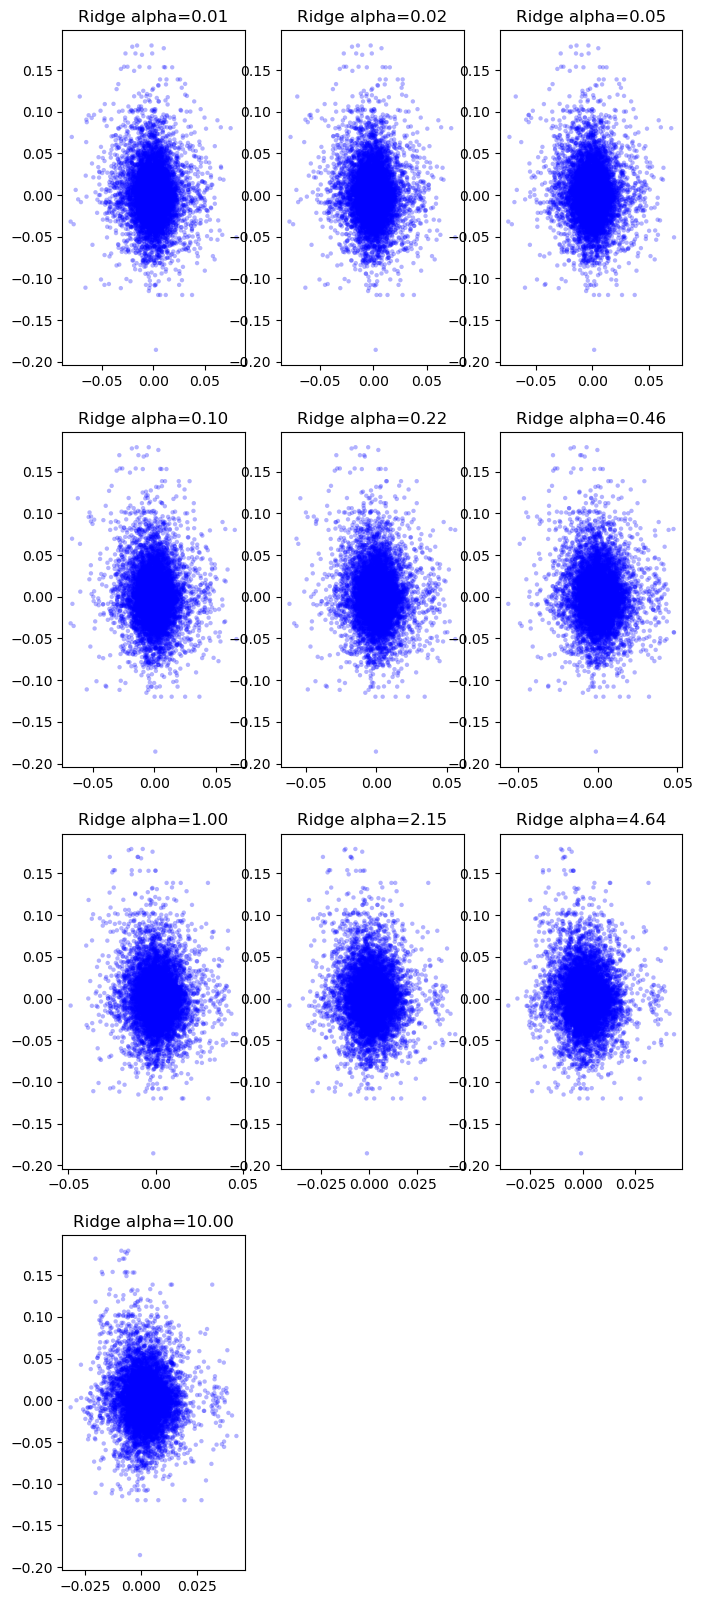

In [322]:
plot_count = len(rd_preds)
col_count = 3
row_count = int(np.ceil(plot_count / col_count))
_, axs = plt.subplots(nrows=row_count, ncols=col_count, figsize=(8, 2 * plot_count))
#_, ax = plt.subplots(nrows=10, ncols=1, figsize=(8, 4 * plot_count))

for i, ax in enumerate(axs.flatten()):
  if i >= plot_count:
    ax.axis("off")
    continue

  alpha = rd_preds[i]["alpha"]
  all_p = pd.concat(rd_preds[i]["predictions"])
  ax.scatter(x=all_p["predicted"], y=all_p["actual"], c="b", s=10, label="b", alpha=0.3, edgecolors='none')
  ax.set_title(f"Ridge alpha={alpha:.2f}")



In [361]:
all_rd_preds = pd.concat(rd_preds)
plot_pred_vs_actual(all_rd_preds, same_scale=True)

TypeError: cannot concatenate object of type '<class 'dict'>'; only Series and DataFrame objs are valid

## Evaluate XGBoost

In [362]:
# Evalulate  XGBoost
# We could evaluate Lasso
# TODO: Use optuna to eval several models
xgbr_scores = []
xgbr_preds = []
xgbr_coefs = []
model = XGBRegressor()
X, y = get_data_for_model(main_df)
pip = create_preprocess_pipeline(cat_cols=cat_cols)
pip = add_model(pip, model)
xgbr_res = eval(X, y, pip)
xgbr_preds = xgbr_res["predictions"]
xgbr_scores = xgbr_res["scores"]
# rd_scores.append({"alpha": alpha, "scores": rd_res["scores"]})
# rd_preds.append({"alpha": alpha, "predictions": rd_res["predictions"]})
# rd_coefs.append({"alpha": alpha, "coefs": rd_res["coefs"]})

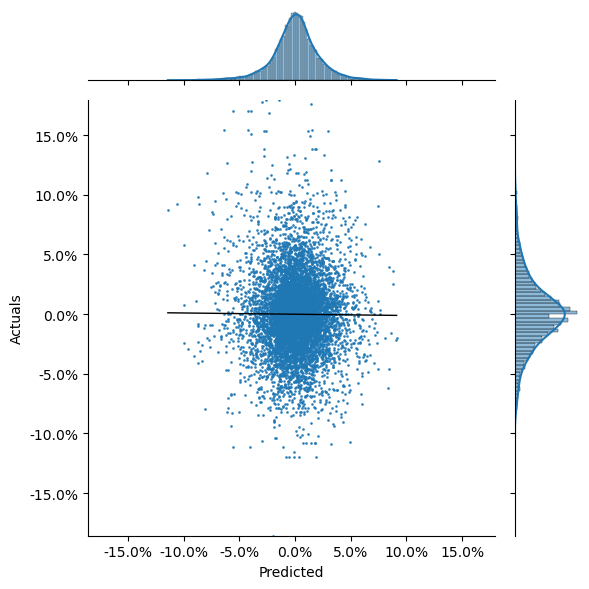

In [363]:
all_xgbr_preds = pd.concat(xgbr_preds)
plot_pred_vs_actual(all_xgbr_preds, same_scale=True)

In [ ]:
plot_count = len(rd_preds)
col_count = 3
row_count = int(np.ceil(plot_count / col_count))
_, axs = plt.subplots(nrows=row_count, ncols=col_count, figsize=(8, 2 * plot_count))
#_, ax = plt.subplots(nrows=10, ncols=1, figsize=(8, 4 * plot_count))

for i, ax in enumerate(axs.flatten()):
  if i >= plot_count:
    ax.axis("off")
    continue

  alpha = rd_preds[i]["alpha"]
  all_p = pd.concat(rd_preds[i]["predictions"])
  ax.scatter(x=all_p["predicted"], y=all_p["actual"], c="b", s=10, label="b", alpha=0.3, edgecolors='none')
  ax.set_title(f"Ridge alpha={alpha:.2f}")